# Classical Machine Learning Models

## Objective

This notebook trains and evaluates classical machine learning models using the handcrafted image features extracted in the previous notebook.

The primary objectives are:

- Load the engineered feature dataset
- Prepare the data for model training
- Train Random Forest and XGBoost classifiers
- Evaluate both models using Stratified 5-Fold Cross Validation
- Compare their performance
- Analyze feature importance
- Save the trained XGBoost model for future inference

## Load the Engineered Feature Dataset

Load the handcrafted feature dataset generated during feature engineering. This dataset serves as the input for all classical machine learning experiments.

In [37]:
import pandas as pd

df = pd.read_csv("../engineered_features.csv")

In [38]:
df.to_csv("../engineered_features.csv", index=False)

## Encode Class Labels

Convert the categorical target labels into numerical values suitable for machine learning algorithms.

In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["label"] = le.fit_transform(df["label"])

df.head()

,width,height,brightness,contrast,laplacian,edge_density,fft_mean,fft_std,low_energy,high_energy,...,lbp_18,lbp_19,lbp_20,lbp_21,lbp_22,lbp_23,lbp_24,lbp_25,label,filename
0,1280,720,86.843356,72.940512,133.974220,0.028845,7.793761,0.988023,10.290016,7.731292,...,0.012680,0.013504,0.013290,0.016449,0.023026,0.024994,0.077499,0.361893,0,image_33.jpeg
1,899,1599,121.585207,53.212329,105.850217,0.020094,7.761115,0.901080,10.001509,7.705049,...,0.016220,0.016220,0.016983,0.019333,0.022308,0.020813,0.064056,0.348816,0,image_25.jpeg
2,1200,1600,115.583521,63.082602,113.837940,0.015818,7.921058,0.871474,9.770370,7.874779,...,0.010101,0.010086,0.009521,0.011887,0.017670,0.026886,0.045639,0.438065,0,image_48.jpeg
3,725,1600,128.303312,53.400933,724.985416,0.142362,8.079321,0.868069,10.258146,8.024796,...,0.006439,0.006744,0.006927,0.009613,0.014587,0.033936,0.057968,0.493637,0,image_6.jpeg
4,720,1600,127.736346,54.394504,1334.930272,0.091699,8.085114,0.886723,10.162933,8.033116,...,0.009964,0.010635,0.010254,0.015076,0.019928,0.036377,0.090851,0.478714,0,image_29.jpeg


## Separate Features and Target

Split the dataset into input features and the target class that will be predicted by the classifiers.

In [40]:
X = df.drop(columns=[
    "label",
    "filename",
    "width",
    "height"
])

y = df["label"]

## Train-Test Split

Create a training and testing split that can be used for initial experimentation before cross-validation.

In [41]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

## Train the Random Forest Classifier

Initialize and train a Random Forest classifier using the engineered image features.

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(

    n_estimators=300,

    random_state=42

)

rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

## Evaluate Random Forest Performance

Measure the predictive performance of the trained Random Forest model using standard classification metrics.

In [43]:
from sklearn.metrics import accuracy_score

pred = rf.predict(X_test)

print(accuracy_score(y_test,pred))

0.7619047619047619


## Analyze Feature Importance

Visualize the importance assigned to each handcrafted feature by the Random Forest model.

This provides insight into which image characteristics contribute most to distinguishing real photographs from screen recaptures.

In [44]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(20)

,Feature,Importance
22,v_std,0.141079
14,r_std,0.112897
1,contrast,0.060791
15,g_std,0.056669
5,fft_std,0.048030
16,b_std,0.045549
24,hog_std,0.034886
51,lbp_22,0.031705
23,hog_mean,0.029408
20,h_std,0.029030


## Import Cross Validation Utilities

Import Stratified K-Fold Cross Validation to obtain reliable model evaluation across multiple dataset splits.

In [47]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier

## Configure Random Forest

Define the Random Forest model with the selected hyperparameters.

In [48]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

## Configure Stratified 5-Fold Cross Validation

Create a Stratified K-Fold splitter to preserve class balance across every validation fold.

In [49]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Define Evaluation Metrics

Specify the evaluation metrics that will be computed during cross-validation.

The selected metrics include:

- Accuracy
- Precision
- Recall
- F1 Score

In [50]:
scoring = [
    "accuracy",
    "precision",
    "recall",
    "f1"
]

scores = cross_validate(
    rf,
    X,
    y,
    cv=cv,
    scoring=scoring
)

## Cross Validation Results

Display the evaluation scores obtained on every validation fold.

In [51]:
print("Accuracy :", scores["test_accuracy"])
print()

print("Precision:", scores["test_precision"])
print()

print("Recall   :", scores["test_recall"])
print()

print("F1 Score :", scores["test_f1"])

Accuracy : [0.80952381 0.9047619  0.7        0.8        0.8       ]

Precision: [1.         1.         0.64285714 0.8        0.8       ]

Recall   : [0.6        0.81818182 0.9        0.8        0.8       ]

F1 Score : [0.75 0.9  0.75 0.8  0.8 ]


## Average Random Forest Performance

Compute the mean performance across all folds to estimate the generalization ability of the Random Forest classifier.

In [52]:
print(f"Mean Accuracy : {scores['test_accuracy'].mean():.4f}")
print(f"Std Accuracy  : {scores['test_accuracy'].std():.4f}")

print()

print(f"Mean Precision : {scores['test_precision'].mean():.4f}")
print(f"Mean Recall    : {scores['test_recall'].mean():.4f}")
print(f"Mean F1 Score  : {scores['test_f1'].mean():.4f}")

Mean Accuracy : 0.8029
Std Accuracy  : 0.0648

Mean Precision : 0.8486
Mean Recall    : 0.7836
Mean F1 Score  : 0.8000


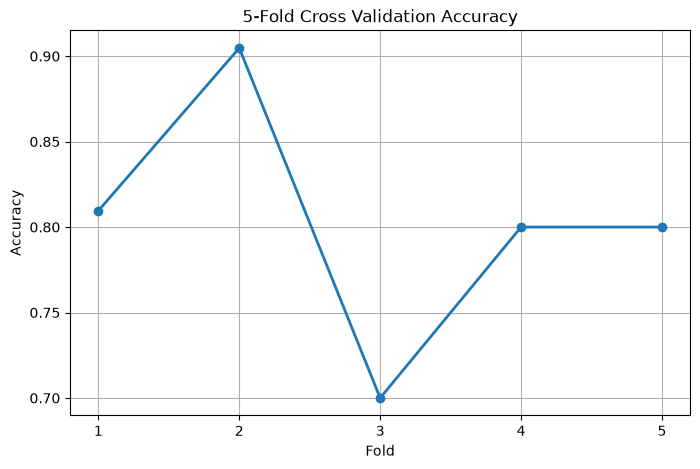

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1,6),
    scores["test_accuracy"],
    marker="o",
    linewidth=2
)

plt.xticks(range(1,6))
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross Validation Accuracy")

plt.grid(True)

plt.show()

## Import XGBoost

Import the XGBoost classifier for the second classical machine learning experiment.

In [54]:
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate

## Configure the XGBoost Classifier

Initialize the XGBoost model using the selected training parameters.

In [55]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

In [56]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Evaluate XGBoost

Run Stratified 5-Fold Cross Validation and collect the evaluation scores for every fold.

In [57]:
scoring = [
    "accuracy",
    "precision",
    "recall",
    "f1"
]

scores = cross_validate(
    xgb,
    X,
    y,
    cv=cv,
    scoring=scoring
)

In [58]:
print("Accuracy :", scores["test_accuracy"])
print()

print("Precision:", scores["test_precision"])
print()

print("Recall   :", scores["test_recall"])
print()

print("F1 Score :", scores["test_f1"])

Accuracy : [0.80952381 0.9047619  0.8        0.85       0.8       ]

Precision: [1.         1.         0.75       0.88888889 0.8       ]

Recall   : [0.6        0.81818182 0.9        0.8        0.8       ]

F1 Score : [0.75       0.9        0.81818182 0.84210526 0.8       ]


In [59]:
print(f"Mean Accuracy : {scores['test_accuracy'].mean():.4f}")
print(f"Std Accuracy  : {scores['test_accuracy'].std():.4f}")

print()

print(f"Mean Precision : {scores['test_precision'].mean():.4f}")
print(f"Mean Recall    : {scores['test_recall'].mean():.4f}")
print(f"Mean F1 Score  : {scores['test_f1'].mean():.4f}")

Mean Accuracy : 0.8329
Std Accuracy  : 0.0404

Mean Precision : 0.8878
Mean Recall    : 0.7836
Mean F1 Score  : 0.8221


## Train the Final XGBoost Model

Train the XGBoost classifier using the complete engineered feature dataset before deployment.

In [60]:
xgb.fit(X, y)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## Prepare Feature Importance

Create a DataFrame containing the learned feature importance scores.

In [61]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
22,v_std,0.098727
14,r_std,0.075864
19,v_mean,0.054715
54,lbp_25,0.052566
5,fft_std,0.038128
1,contrast,0.037528
2,laplacian,0.032803
24,hog_std,0.027924
53,lbp_24,0.026213
32,lbp_3,0.025621


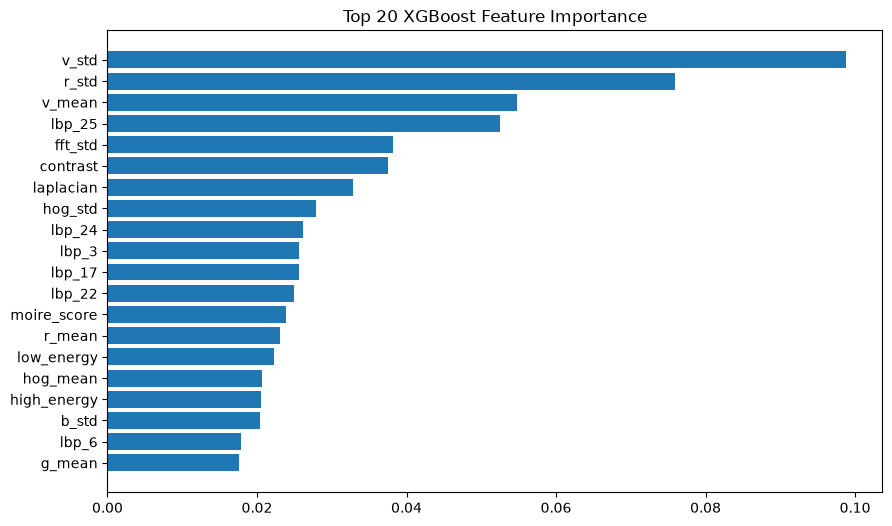

In [62]:
import matplotlib.pyplot as plt

top = importance.head(20)

plt.figure(figsize=(10,6))

plt.barh(top["Feature"], top["Importance"])

plt.gca().invert_yaxis()

plt.title("Top 20 XGBoost Feature Importance")

plt.show()

## Save the Trained Model

Store the trained XGBoost model so that it can be reused without retraining.

In [65]:
xgb.save_model("../models/xgb_model.json")

# Summary

This notebook established classical machine learning baselines for the screen recapture detection task using handcrafted image features.

### Models Evaluated

- Random Forest
- XGBoost

### Evaluation Strategy

- Stratified 5-Fold Cross Validation
- Accuracy
- Precision
- Recall
- F1 Score

### Results

The Random Forest classifier achieved a mean accuracy of approximately **80.29%**, while XGBoost improved the overall performance to approximately **83.29%**.

Feature importance analysis showed that frequency-domain and texture-based descriptors contributed most significantly to the classification task.

Although these classical models produced competitive results, the subsequent notebooks investigate transfer learning with convolutional neural networks to further improve classification performance.